<a href="https://colab.research.google.com/github/Rytham1/song-popularity-predictor/blob/main/ecs_171_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction

Predicting what makes a song popular is a question that has long interested the music industry, and with the rise of streaming platforms like Spotify, large-scale audio
data has made it possible to approach this question quantitatively. In this project, we investigate whether a song's popularity can be predicted from its audio features using 
attributes such as danceability, energy, tempo, loudness, and valence while using a dataset of over 32,000 Spotify tracks spanning six genres.

We initially framed this as a regression problem, attempting to predict a song's raw popularity score. However, all regression models yielded poor results (R² ≈ 0.20),
suggesting that audio features alone explain very little of the continuous variance in popularity. We then pivoted to a binary classification approach, labeling songs as
"Hit" (top 25% popularity) or "Not Hit" (bottom 75%), which allowed us to ask a simpler but more actionable question: can we identify whether a song will be popular,
even if we cannot predict exactly how popular it will be?

Our pipeline includes EDA, Feature analysis, Data preprocessing with outlier clipping and standard scaling, one-hot encoding of genre features, and an engineered artist popularity feature. We
trained and tuned five classifiers, KNN, Neural Network, Logistic Regression, Random Forest, and XGBoost, and kept only the 3 best performing models using five-fold cross-validated grid search, and evaluated them using accuracy, precision, recall, F1 score, and ROC-AUC.

## Libraries

In [60]:
# Libraries
import os
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Loading Dataset

In [61]:
# Load dataset
path = "spotify_songs.csv"
df = pd.read_csv(path)
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


## Exploratory Data Analysis (EDA)

Looking at distributions, boxplots, and correlation heatmaps to understand our features.

In [62]:
print("df.shape:", df.shape)

dupe_song = df.duplicated(subset=["track_name", "track_artist"]).sum()
print("Duplicates by (track_name, track_artist):", dupe_song)

dupe_id = df.duplicated(subset=["track_id"]).sum()
print("Duplicates by track_id:", dupe_id)

df.shape: (32833, 23)
Duplicates by (track_name, track_artist): 6603
Duplicates by track_id: 4477


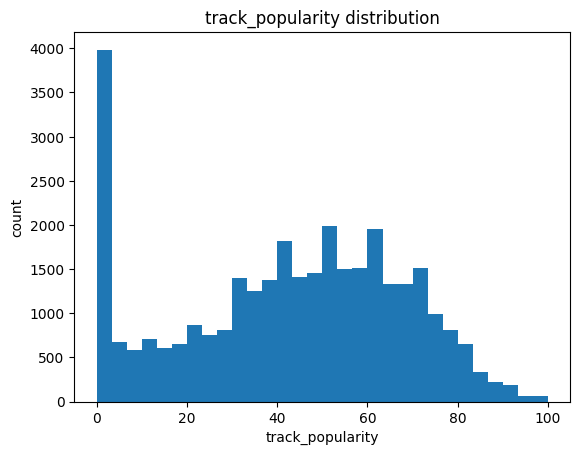

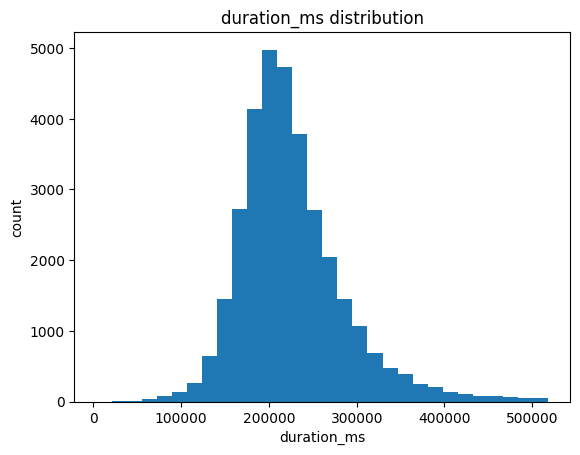

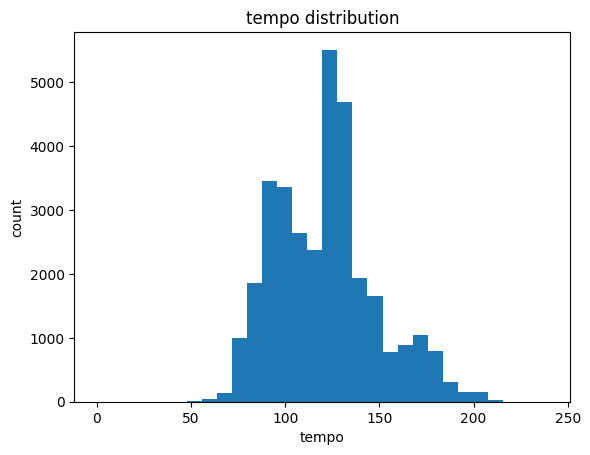

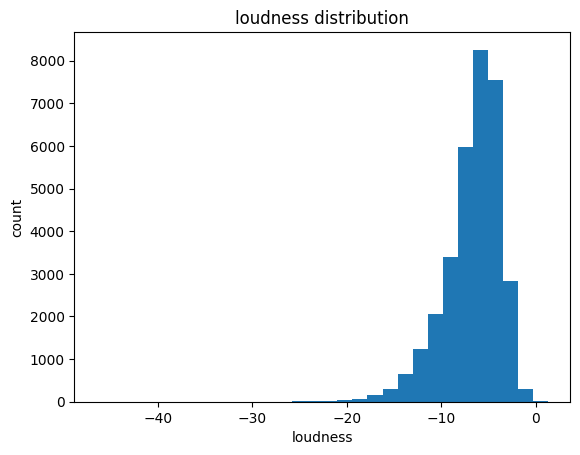

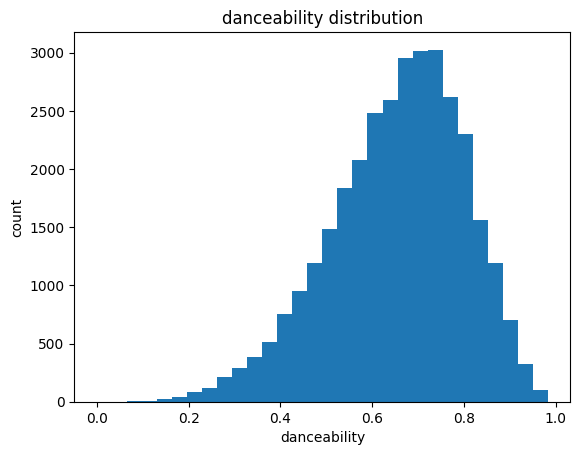

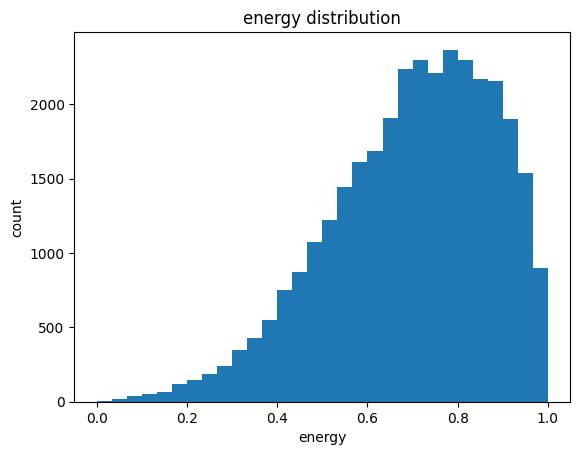

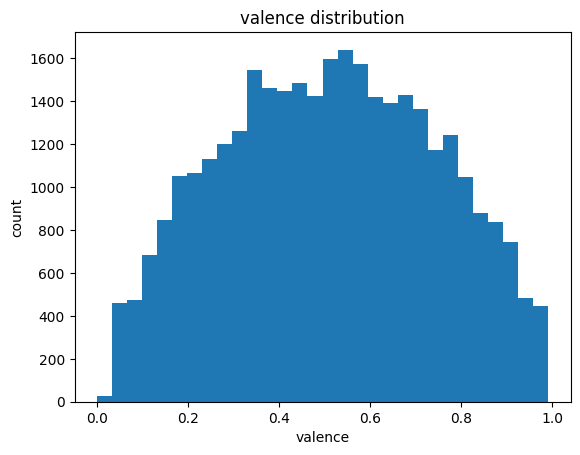

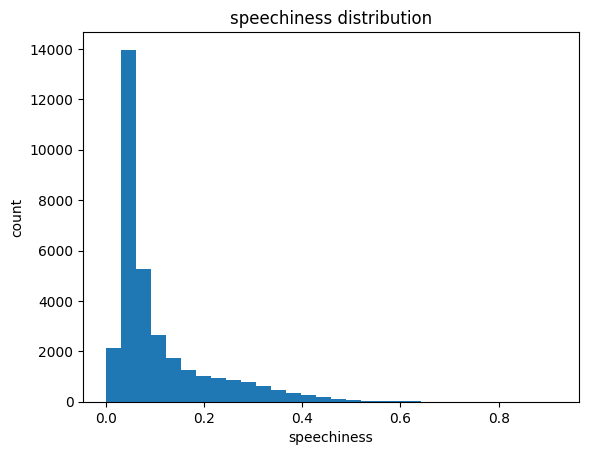

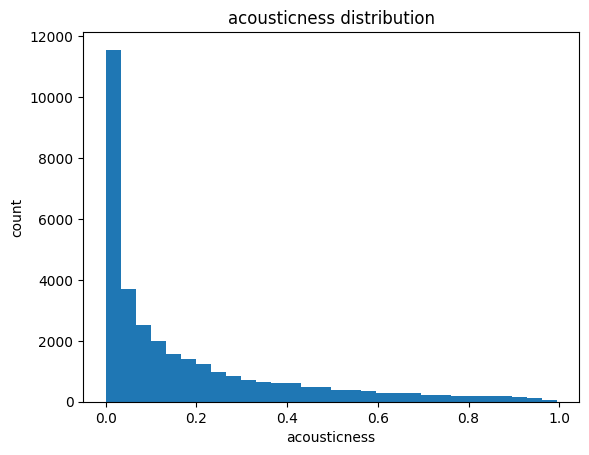

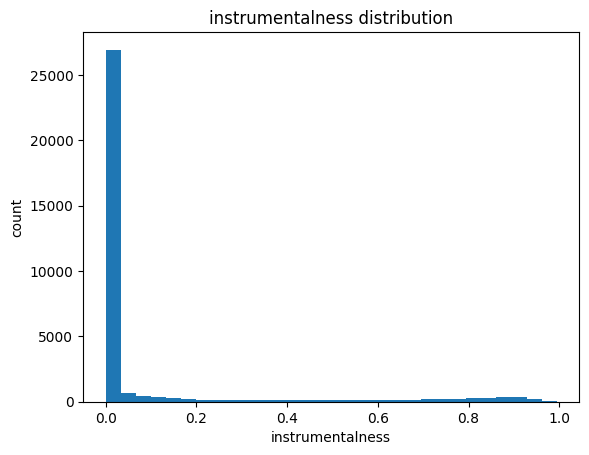

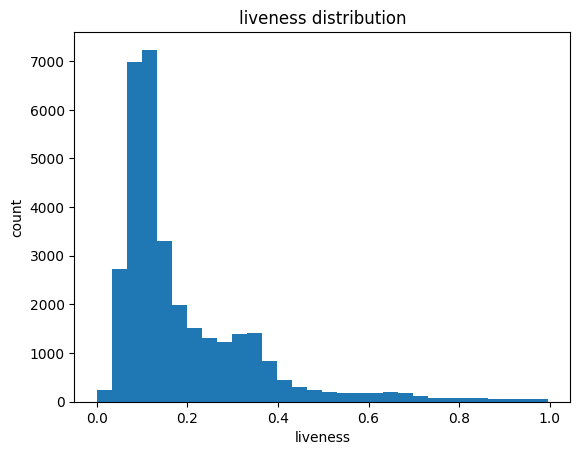

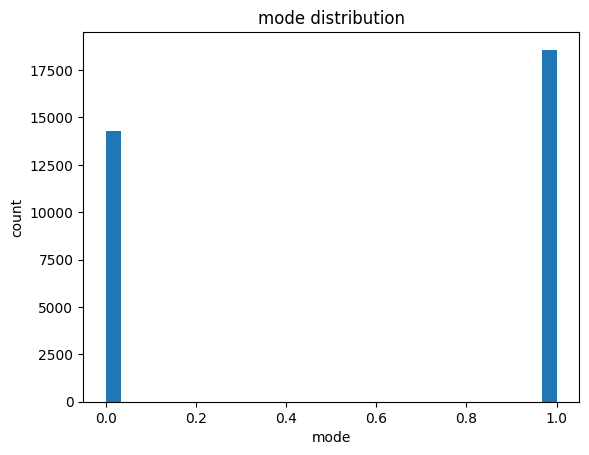

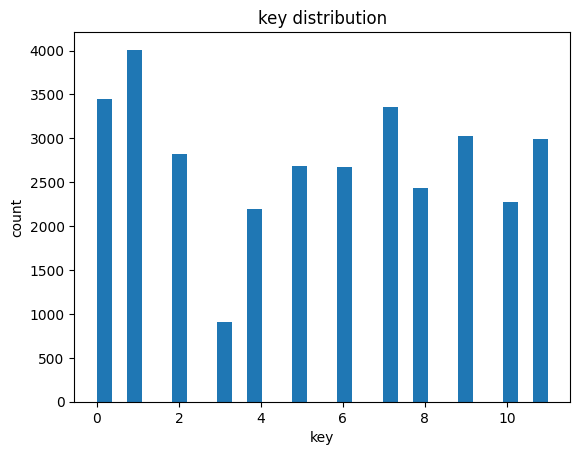

In [63]:
features = [f for f in ["track_popularity","duration_ms","tempo","loudness","danceability","energy","valence","speechiness","acousticness","instrumentalness","liveness","mode","key"]]
for f in features:
    plt.figure()
    plt.hist(df[f].dropna(), bins=30)
    plt.title(f"{f} distribution")
    plt.xlabel(f)
    plt.ylabel("count")
    plt.show()


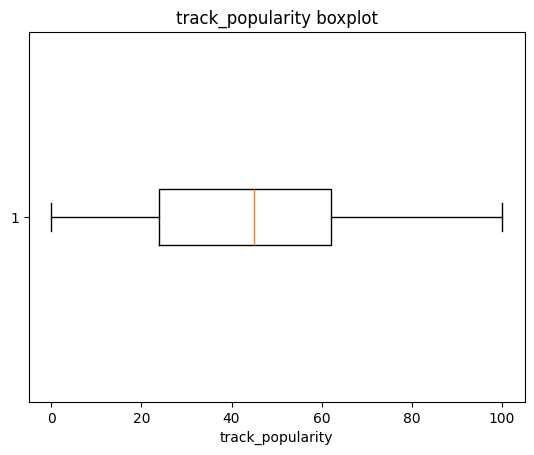

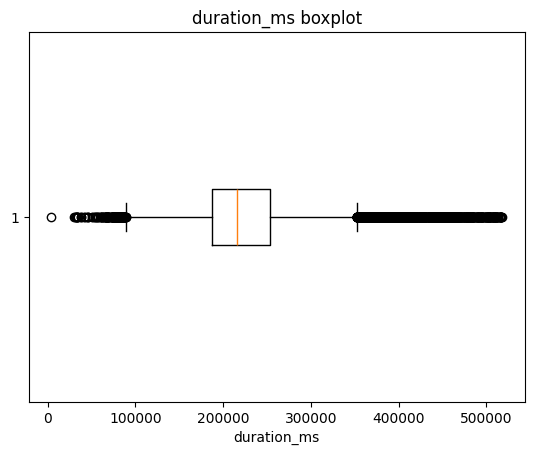

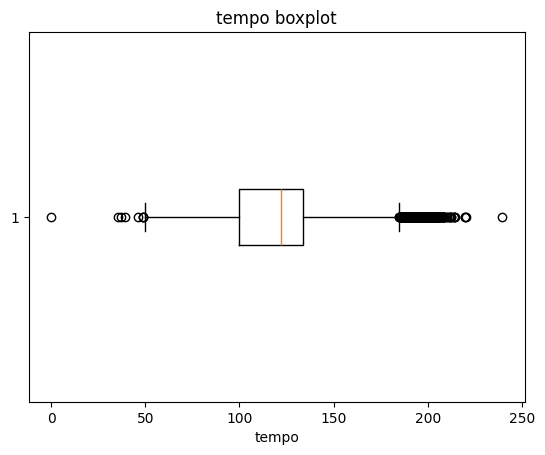

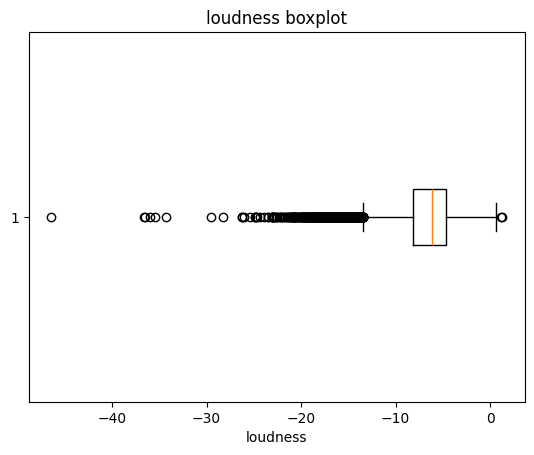

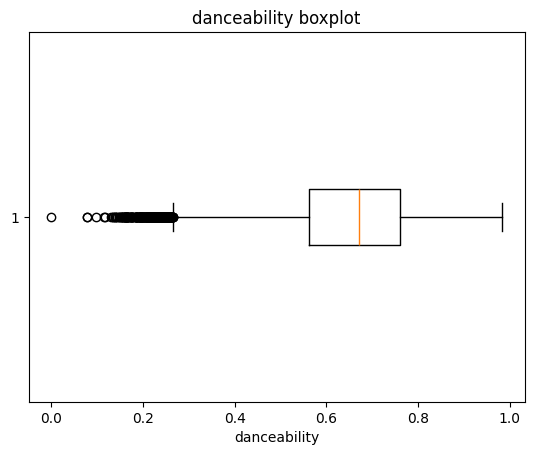

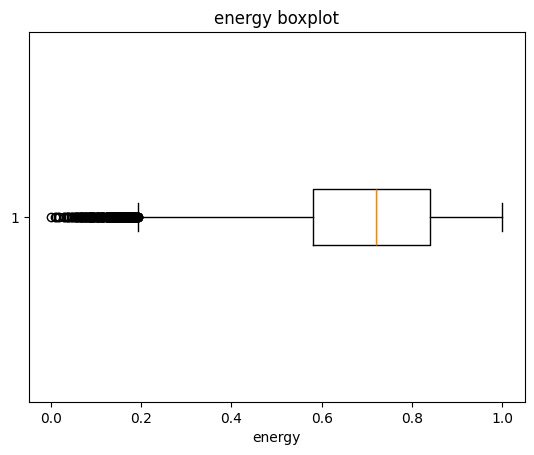

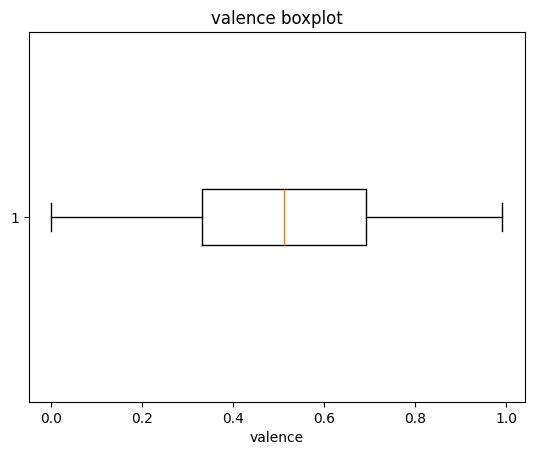

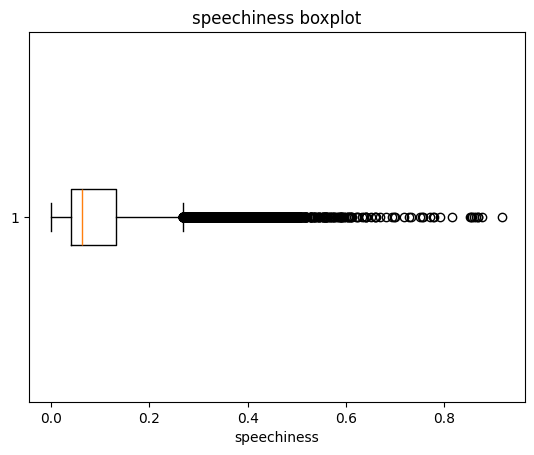

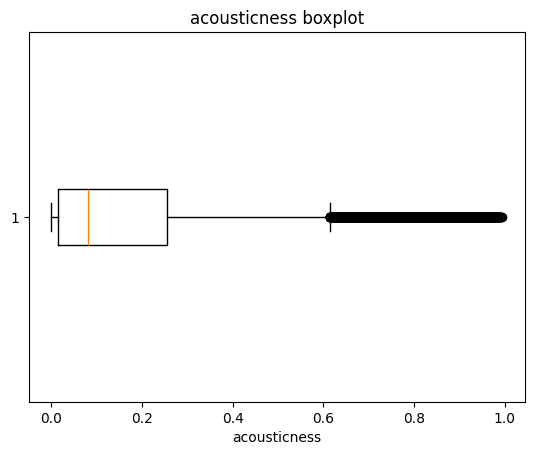

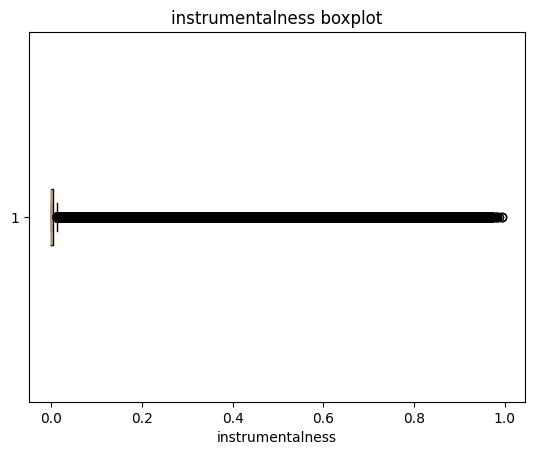

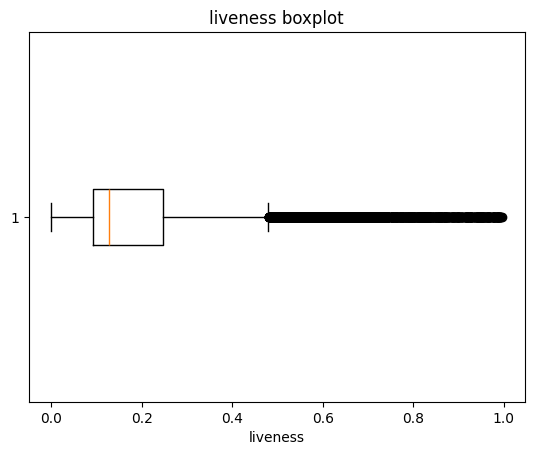

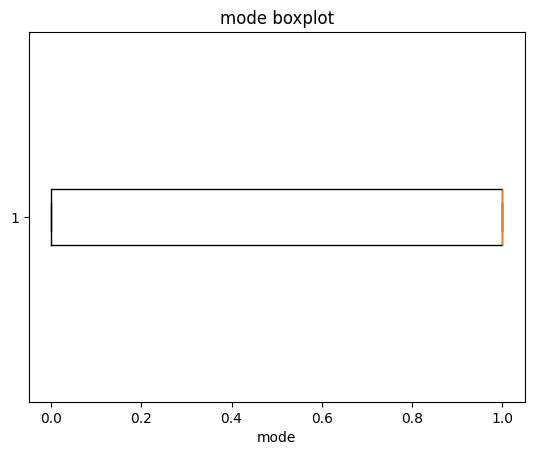

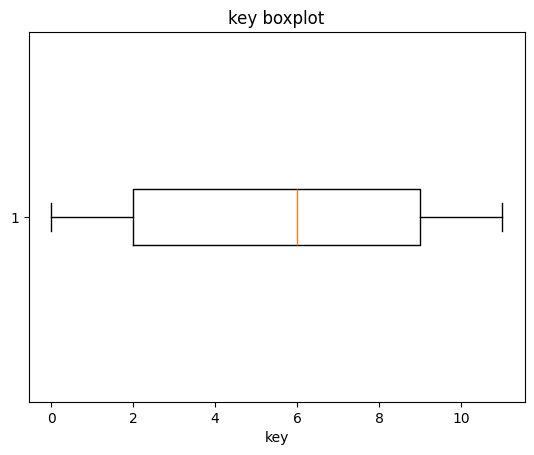

In [64]:
features = [f for f in ["track_popularity","duration_ms","tempo","loudness","danceability","energy","valence","speechiness","acousticness","instrumentalness","liveness","mode","key"]]

for f in features:
    plt.figure()
    plt.boxplot(df[f].dropna(), vert=False, showfliers=True)  # showfliers=True shows outliers
    plt.title(f"{f} boxplot")
    plt.xlabel(f)
    plt.show()

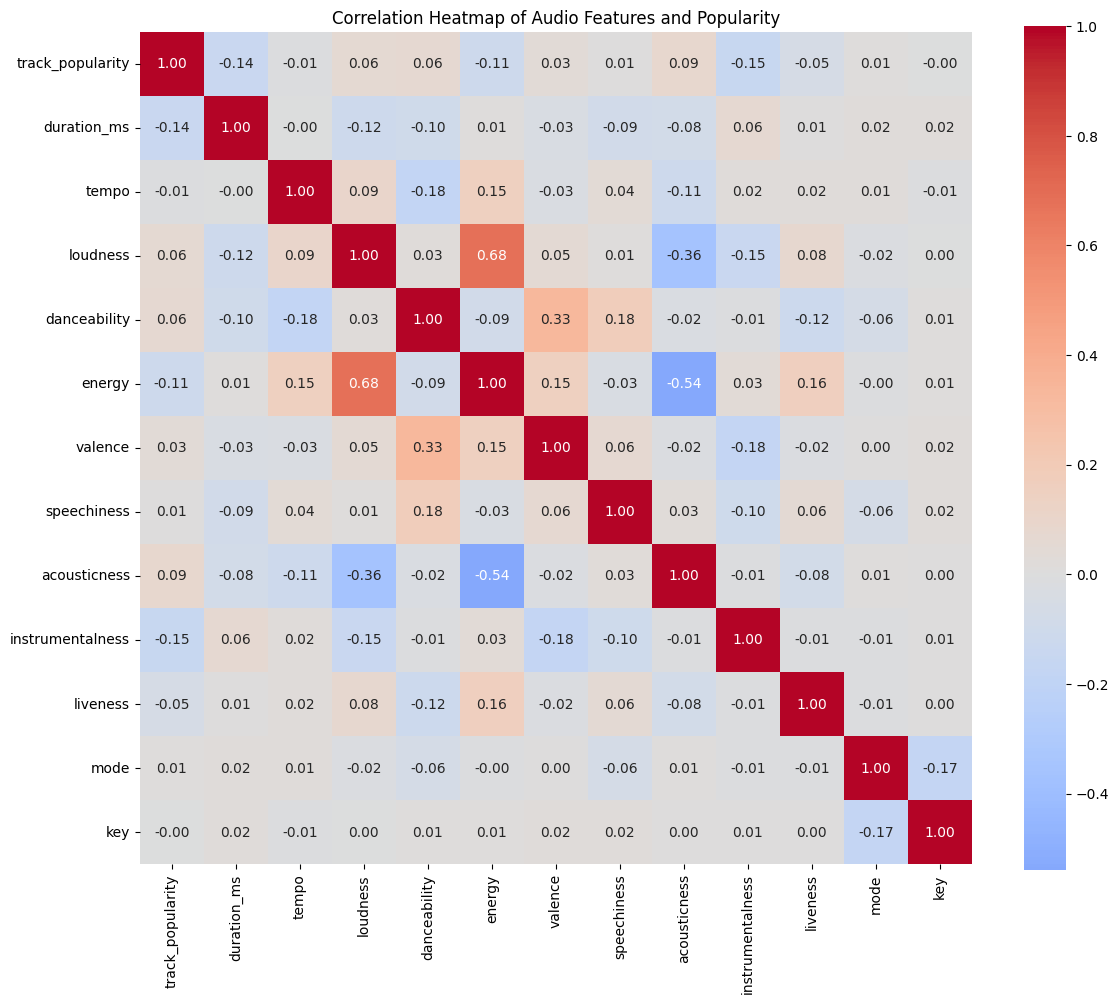

In [65]:
features = [f for f in ["track_popularity","duration_ms","tempo","loudness","danceability","energy","valence","speechiness","acousticness","instrumentalness","liveness","mode","key"]]
correlation_matrix = df[features].corr()
plt.figure(figsize = (12, 10))
sns.heatmap(correlation_matrix, annot = True, fmt = ".2f", cmap = "coolwarm",
            center = 0, square = True)
plt.title("Correlation Heatmap of Audio Features and Popularity")
plt.tight_layout()
plt.show()


## Feature Analysis

Checking how many unique values each categorical column has, and whether release year is worth including.

In [66]:
"""
Checking how many unique artists we have.
Artist name is imporant for track popularity but if it is too many unique values, we have to drop it.
This is because, we will have to do one-hot-encoding, leading to too many columns.
"""

unique_artists = df["track_artist"].nunique()
print("unique values for artists: ", unique_artists)

# we should one hot encode this since it is low (6 unique)
unique_genre= df["playlist_genre"].nunique()
print("unique values for genre: ", unique_genre)

# same here, one hot encode this (24 unique)
unique_subgenre = df["playlist_subgenre"].nunique()
print("unique values for subgenre: ", unique_subgenre)

unique values for artists:  10692
unique values for genre:  6
unique values for subgenre:  24


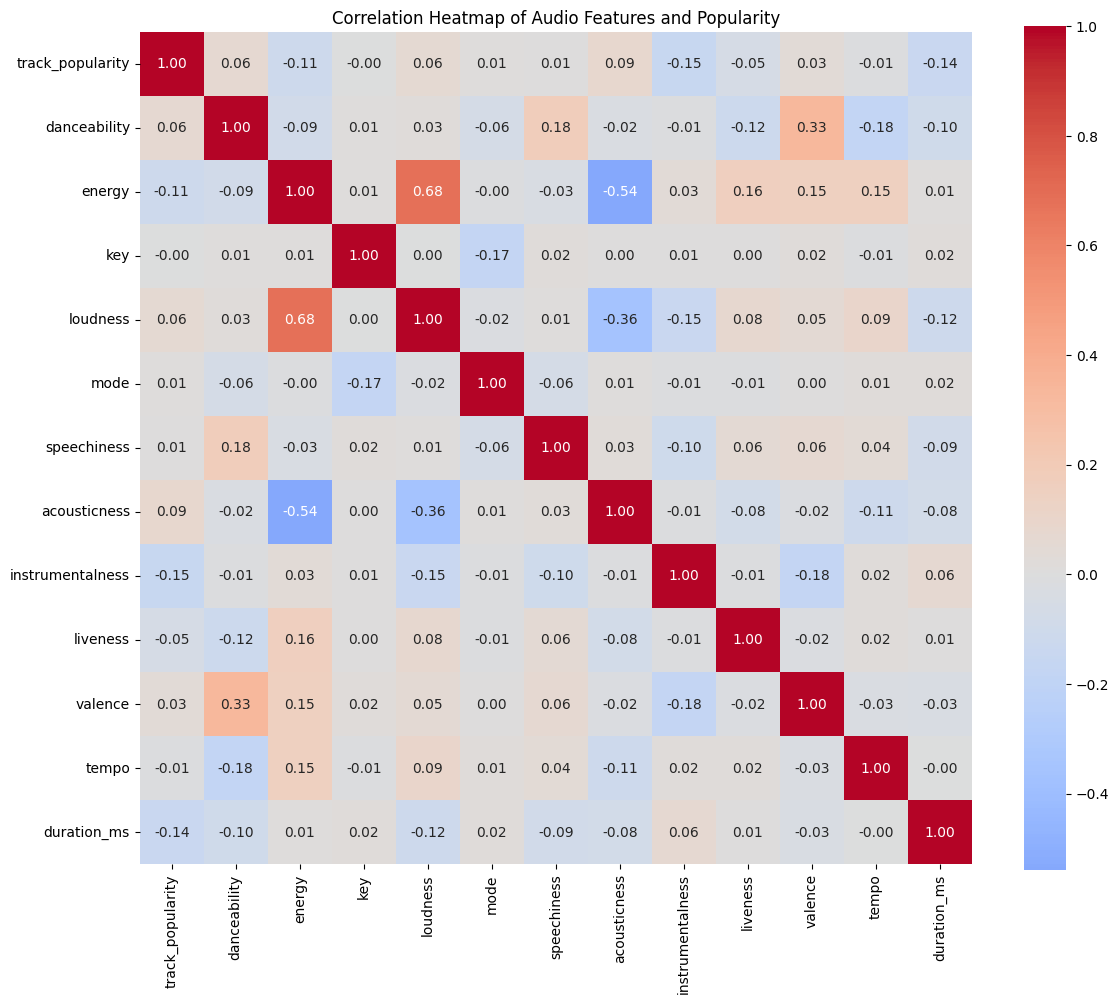

In [67]:
# Correlation matrix for all features that have numerical values
numeric_df = df.select_dtypes(include=['number'])
full_correlation_matrix = numeric_df.corr()

plt.figure(figsize = (12, 10))
sns.heatmap(full_correlation_matrix, annot = True, fmt = ".2f", cmap = "coolwarm",
            center = 0, square = True)
plt.title("Correlation Heatmap of Audio Features and Popularity")
plt.tight_layout()
plt.show()

In [68]:
# checking if release year correlates with popularity
release_year = (pd.to_datetime(df["track_album_release_date"], format="mixed")).dt.year
corr = release_year.corr(df["track_popularity"])
print(f"Correlation between release_year and track_popularity: {corr:.4f}")
print(f"Conclusion: Very low correlation ({corr:.2f}) - not worth including as a feature.")

Correlation between release_year and track_popularity: 0.0607
Conclusion: Very low correlation (0.06) - not worth including as a feature.


## Data Preprocessing

Dropping duplicates, one-hot encoding genres, computing avg artist popularity, clipping outliers with IQR, scaling, and splitting into train/test.

In [69]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

numeric_feature_columns = [
    "duration_ms",
    "tempo",
    "loudness",
    "danceability",
    "energy",
    "valence",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "mode",
    "key",
]

categorical_feature_columns = [
    "playlist_genre",
    "playlist_subgenre",
]

target_column = "track_popularity"

artist_column = "track_artist"

In [70]:
def compute_iqr_bounds(
    numeric_series: pd.Series, iqr_multiplier: float = 1.5
) -> tuple[float, float]:
    first_quartile = numeric_series.quantile(0.25)
    third_quartile = numeric_series.quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    lower_bound = first_quartile - iqr_multiplier * interquartile_range
    upper_bound = third_quartile + iqr_multiplier * interquartile_range
    return lower_bound, upper_bound


def fit_iqr_outlier_bounds(
    training_features: pd.DataFrame,
    numeric_feature_columns: list[str],
    iqr_multiplier: float = 1.5,
) -> dict[str, tuple[float, float]]:
    feature_to_bounds = {}
    for feature_name in numeric_feature_columns:
        non_null_values = training_features[feature_name].dropna()
        lower_bound, upper_bound = compute_iqr_bounds(
            non_null_values, iqr_multiplier=iqr_multiplier
        )
        feature_to_bounds[feature_name] = (lower_bound, upper_bound)
    return feature_to_bounds


def apply_outlier_clipping(
    feature_frame: pd.DataFrame,
    feature_to_bounds: dict[str, tuple[float, float]],
) -> pd.DataFrame:

    clipped_features = feature_frame.copy()

    for feature_name, (lower_bound, upper_bound) in feature_to_bounds.items():
        clipped_features[feature_name] = clipped_features[feature_name].clip(
            lower_bound, upper_bound
        )

    return clipped_features


def preprocess_split_and_scale(
    raw_dataframe: pd.DataFrame,
    numeric_cols: list[str],
    categorical_cols: list[str],
    target_col: str,
    artist_col=None,
    test_fraction: float = 0.2,
    iqr_multiplier: float = 1.5,
):

    working_dataframe = raw_dataframe.copy()

    # drop duplicate songs (same name + artist) so the same song doesn't end up in both train and test
    working_dataframe = working_dataframe.drop_duplicates(
        subset=["track_name", "track_artist"], keep="first"
    )

    # only keep the columns we need
    needed_cols = numeric_cols + categorical_cols + [target_col]
    if artist_col is not None:
        needed_cols.append(artist_col)
    working_dataframe = working_dataframe[needed_cols].dropna(subset=[target_col])

    # one-hot encode genre and subgenre (drop_first to avoid multicollinearity)
    working_dataframe = pd.get_dummies(
        working_dataframe, columns=categorical_cols, drop_first=True
    )

    # grab the one-hot column names that were just created
    onehot_cols = [
        c for c in working_dataframe.columns
        if any(c.startswith(cat + "_") for cat in categorical_cols)
    ]

    numeric_cols = list(numeric_cols)
    all_feature_cols = numeric_cols + onehot_cols

    # train/test split
    feature_matrix = working_dataframe[all_feature_cols]
    target_vector = working_dataframe[target_col]

    training_features, test_features, training_target, test_target = train_test_split(
        feature_matrix, target_vector, test_size=test_fraction, random_state=42
    )

    # artist mean encoding: for each artist, compute their avg song popularity from training data only
    if artist_col is not None:
        artist_series = working_dataframe[artist_col]
        train_artists = artist_series.loc[training_features.index]
        test_artists = artist_series.loc[test_features.index]

        global_train_mean = training_target.mean()

        # group by artist and get their mean popularity (training set only)
        artist_mean_popularity = (
            pd.DataFrame({"artist": train_artists, "popularity": training_target})
            .groupby("artist")["popularity"]
            .mean()
        )

        # if an artist wasn't in training data, fall back to the overall average
        train_avg = train_artists.map(artist_mean_popularity).fillna(global_train_mean)
        test_avg = test_artists.map(artist_mean_popularity).fillna(global_train_mean)

        training_features = training_features.copy()
        test_features = test_features.copy()

        training_features["artist_avg_popularity"] = train_avg.values
        test_features["artist_avg_popularity"] = test_avg.values

        numeric_cols.append("artist_avg_popularity")
        all_feature_cols.append("artist_avg_popularity")

    # clip outliers using IQR bounds (fitted on training data)
    fitted_outlier_bounds = fit_iqr_outlier_bounds(
        training_features=training_features,
        numeric_feature_columns=numeric_cols,
        iqr_multiplier=iqr_multiplier,
    )

    training_features = apply_outlier_clipping(
        feature_frame=training_features, feature_to_bounds=fitted_outlier_bounds
    )

    test_features = apply_outlier_clipping(
        feature_frame=test_features, feature_to_bounds=fitted_outlier_bounds
    )

    # scale numeric columns to zero mean / unit variance (don't touch one-hot cols)
    fitted_scaler = StandardScaler()
    training_features[numeric_cols] = fitted_scaler.fit_transform(
        training_features[numeric_cols]
    )
    test_features[numeric_cols] = fitted_scaler.transform(
        test_features[numeric_cols]
    )

    feature_names = all_feature_cols

    return (
        training_features.values,
        test_features.values,
        training_target,
        test_target,
        fitted_scaler,
        fitted_outlier_bounds,
        feature_names,
    )


def summarize_iqr_outliers(
    raw_dataframe: pd.DataFrame,
    numeric_feature_columns: list[str],
    iqr_multiplier: float = 1.5,
) -> pd.DataFrame:

    summary_rows = []
    for feature_name in numeric_feature_columns:
        non_null_values = raw_dataframe[feature_name].dropna()
        lower_bound, upper_bound = compute_iqr_bounds(
            non_null_values, iqr_multiplier=iqr_multiplier
        )
        non_null_count = raw_dataframe[feature_name].notna().sum()
        outlier_count = (
            (raw_dataframe[feature_name] < lower_bound)
            | (raw_dataframe[feature_name] > upper_bound)
        ).sum()
        outlier_rate = outlier_count / max(non_null_count, 1)
        summary_rows.append(
            {
                "feature_name": feature_name,
                "non_null_count": int(non_null_count),
                "outlier_count": int(outlier_count),
                "outlier_rate": float(outlier_rate),
                "lower_bound": float(lower_bound),
                "upper_bound": float(upper_bound),
            }
        )

    return (
        pd.DataFrame(summary_rows)
        .sort_values("outlier_rate", ascending=False)
        .reset_index(drop=True)
    )

In [71]:
(scaled_training_features, scaled_test_features,
 training_target, test_target,
 fitted_scaler, fitted_outlier_bounds,
 feature_names) = preprocess_split_and_scale(
    raw_dataframe=df,
    numeric_cols=numeric_feature_columns,
    categorical_cols=categorical_feature_columns,
    target_col=target_column,
    artist_col=artist_column,
)

print(f"Training shape: {scaled_training_features.shape}")
print(f"Test shape:     {scaled_test_features.shape}")
print(f"Total features: {len(feature_names)}")
print(f"Feature names:  {feature_names}")

outlier_summary_table = summarize_iqr_outliers(df, numeric_feature_columns)
outlier_summary_table.head(10)

Training shape: (20984, 41)
Test shape:     (5246, 41)
Total features: 41
Feature names:  ['duration_ms', 'tempo', 'loudness', 'danceability', 'energy', 'valence', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'mode', 'key', 'playlist_genre_latin', 'playlist_genre_pop', 'playlist_genre_r&b', 'playlist_genre_rap', 'playlist_genre_rock', 'playlist_subgenre_big room', 'playlist_subgenre_classic rock', 'playlist_subgenre_dance pop', 'playlist_subgenre_electro house', 'playlist_subgenre_electropop', 'playlist_subgenre_gangster rap', 'playlist_subgenre_hard rock', 'playlist_subgenre_hip hop', 'playlist_subgenre_hip pop', 'playlist_subgenre_indie poptimism', 'playlist_subgenre_latin hip hop', 'playlist_subgenre_latin pop', 'playlist_subgenre_neo soul', 'playlist_subgenre_new jack swing', 'playlist_subgenre_permanent wave', 'playlist_subgenre_pop edm', 'playlist_subgenre_post-teen pop', 'playlist_subgenre_progressive electro house', 'playlist_subgenre_reggaeton', 'playlist_sub

,feature_name,non_null_count,outlier_count,outlier_rate,lower_bound,upper_bound
0,instrumentalness,32833,7030,0.214114,-0.007245,0.012075
1,speechiness,32833,3176,0.096732,-0.095500,0.268500
2,acousticness,32833,2205,0.067158,-0.344750,0.614850
3,liveness,32833,1843,0.056133,-0.140250,0.480950
4,duration_ms,32833,1387,0.042244,89170.000000,352234.000000
5,loudness,32833,1021,0.031097,-13.460000,0.644000
6,tempo,32833,571,0.017391,49.023000,184.855000
7,danceability,32833,291,0.008863,0.266000,1.058000
8,energy,32833,277,0.008437,0.192500,1.228500
9,valence,32833,0,0.000000,-0.212000,1.236000


## Regression Models

Training Linear Regression, KNN, Neural Network, Random Forest, and XGBoost regressors, then tuning hyperparameters with GridSearchCV.

In [72]:
X_train = scaled_training_features.astype(float)
X_test = scaled_test_features.astype(float)
y_train = training_target
y_test = test_target

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# KNN (baseline)
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

knn_mae = mean_absolute_error(y_test, y_pred_knn)
knn_mse = mean_squared_error(y_test, y_pred_knn)
knn_r2 = r2_score(y_test, y_pred_knn)

print("KNN MAE:", knn_mae)
print("KNN MSE:", knn_mse)
print("KNN R2:", knn_r2)

KNN MAE: 16.514067861227602
KNN MSE: 453.38700724361416
KNN R2: 0.1476261570718912


In [73]:
# Linear Regression Model

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras

def create_linear_reg_model(input_shape):
    model = keras.Sequential([
        keras.layers.Dense(
            units=1,
            activation='linear',
            input_shape=(input_shape,),
            name='linear_regression_layer'
        )
    ])
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mae', 'mse']
    )
    return model


num_features = X_train.shape[1]
linear_model = create_linear_reg_model(input_shape=num_features)

linear_model.summary()

epochs, batch_size, validation_split = 100, 32, 0.2
history = linear_model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    verbose=1
)
print("Training completed")


y_pred_lr = linear_model.predict(X_test).flatten()
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
print(f"Mean Squared Error (MSE): {lr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.4f}")
print(f"Mean Absolute Error (MAE): {lr_mae:.4f}")
print(f"R² Score: {lr_r2:.4f}")


model_save_path = 'linear_regression_model.keras'
linear_model.save(model_save_path)

ModuleNotFoundError: No module named 'tensorflow'

In [74]:
# Neural Network
from sklearn.neural_network import MLPRegressor

basic_nn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    alpha=0.001,
    random_state=42,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
)

basic_nn_model.fit(X_train, y_train)
y_pred_nn = basic_nn_model.predict(X_test)


nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_mse = mean_squared_error(y_test, y_pred_nn)
nn_r2 = r2_score(y_test, y_pred_nn)

print("NN MSE:", nn_mse)
print("NN MAE:", nn_mae)
print("NN R2:", nn_r2)
print(f"NN converged in {basic_nn_model.n_iter_} iterations")

NN MSE: 425.9482982884645
NN MAE: 15.565996389574599
NN R2: 0.19921130932244946
NN converged in 23 iterations


In [75]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 15.688447347639014
Random Forest MSE: 433.10388841430824
Random Forest R2: 0.18575870094034252


In [76]:
# XGBoost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost MAE:", xgb_mae)
print("XGBoost MSE:", xgb_mse)
print("XGBoost R2:", xgb_r2)

XGBoost MAE: 15.635464668273926
XGBoost MSE: 429.6175231933594
XGBoost R2: 0.19231313467025757


In [77]:
# Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Random Forest tuning
rf_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 2],
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=5, scoring="r2", n_jobs=-1, verbose=1,
)
rf_search.fit(X_train, y_train)
y_pred_rf_tuned = rf_search.predict(X_test)

rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_mse = mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)

print("=== Random Forest (Tuned) ===")
print(f"Best params: {rf_search.best_params_}")
print(f"Best CV R²:  {rf_search.best_score_:.4f}")
print(f"Test MAE: {rf_tuned_mae:.4f}  MSE: {rf_tuned_mse:.4f}  R²: {rf_tuned_r2:.4f}\n")

# XGBoost tuning
xgb_param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4, 6, 8],
}

xgb_search = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid=xgb_param_grid,
    cv=5, scoring="r2", n_jobs=-1, verbose=1,
)
xgb_search.fit(X_train, y_train)
y_pred_xgb_tuned = xgb_search.predict(X_test)

xgb_tuned_mae = mean_absolute_error(y_test, y_pred_xgb_tuned)
xgb_tuned_mse = mean_squared_error(y_test, y_pred_xgb_tuned)
xgb_tuned_r2 = r2_score(y_test, y_pred_xgb_tuned)

print("=== XGBoost (Tuned) ===")
print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV R²:  {xgb_search.best_score_:.4f}")
print(f"Test MAE: {xgb_tuned_mae:.4f}  MSE: {xgb_tuned_mse:.4f}  R²: {xgb_tuned_r2:.4f}\n")

# Neural Network tuning
nn_param_grid = {
    "hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32)],
    "alpha": [0.001, 0.01],
}

nn_search = GridSearchCV(
    MLPRegressor(random_state=42, max_iter=1000, early_stopping=True, validation_fraction=0.1),
    param_grid=nn_param_grid,
    cv=5, scoring="r2", n_jobs=-1, verbose=1,
)
nn_search.fit(X_train, y_train)
y_pred_nn_tuned = nn_search.predict(X_test)

nn_tuned_mae = mean_absolute_error(y_test, y_pred_nn_tuned)
nn_tuned_mse = mean_squared_error(y_test, y_pred_nn_tuned)
nn_tuned_r2 = r2_score(y_test, y_pred_nn_tuned)

print("=== Neural Network (Tuned) ===")
print(f"Best params: {nn_search.best_params_}")
print(f"Best CV R²:  {nn_search.best_score_:.4f}")
print(f"Test MAE: {nn_tuned_mae:.4f}  MSE: {nn_tuned_mse:.4f}  R²: {nn_tuned_r2:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
=== Random Forest (Tuned) ===
Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 300}
Best CV R²:  0.6210
Test MAE: 15.7170  MSE: 435.0134  R²: 0.1822

Fitting 5 folds for each of 12 candidates, totalling 60 fits
=== XGBoost (Tuned) ===
Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Best CV R²:  0.6266
Test MAE: 15.5904  MSE: 427.0883  R²: 0.1971

Fitting 5 folds for each of 6 candidates, totalling 30 fits
=== Neural Network (Tuned) ===
Best params: {'alpha': 0.001, 'hidden_layer_sizes': (128, 64)}
Best CV R²:  0.6256
Test MAE: 15.6091  MSE: 427.3848  R²: 0.1965


      Model       R²       MAE        MSE
 Linear Reg 0.193172 15.665658 429.160692
        KNN 0.147626 16.514068 453.387007
 RF (Tuned) 0.182169 15.716994 435.013449
XGB (Tuned) 0.197068 15.590430 427.088318
 NN (Tuned) 0.196511 15.609082 427.384766


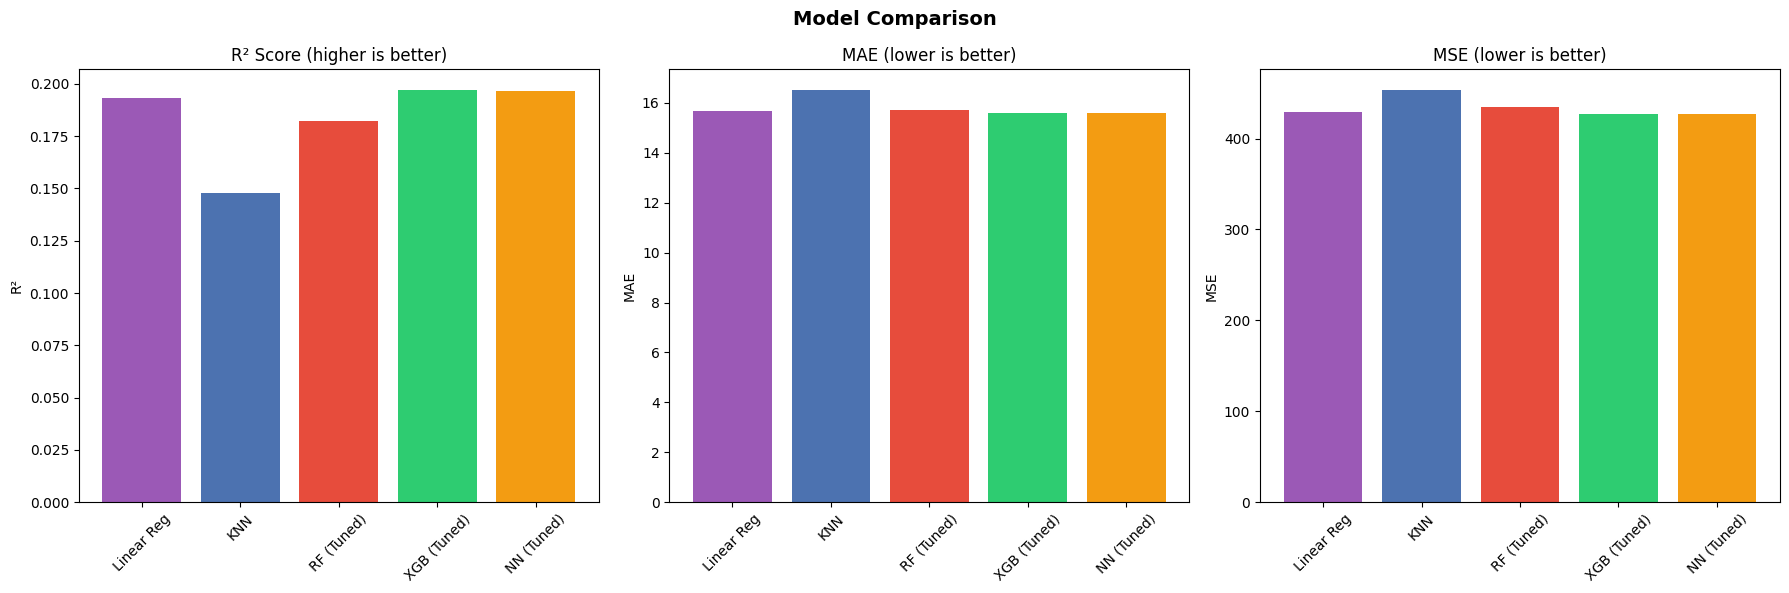

In [78]:
# Comparing all regression models
results = pd.DataFrame({
    "Model": [
        "Linear Reg", "KNN", "RF (Tuned)", "XGB (Tuned)", "NN (Tuned)",
    ],
    "R²": [
        lr_r2, knn_r2,
        rf_tuned_r2, xgb_tuned_r2, nn_tuned_r2,
    ],
    "MAE": [
        lr_mae, knn_mae,
        rf_tuned_mae, xgb_tuned_mae, nn_tuned_mae,
    ],
    "MSE": [
        lr_mse, knn_mse,
        rf_tuned_mse, xgb_tuned_mse, nn_tuned_mse,
    ],
})

print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ["#9B59B6", "#4C72B0", "#E74C3C", "#2ECC71", "#F39C12"]

for ax, metric, title in zip(
    axes,
    ["R²", "MAE", "MSE"],
    ["R² Score (higher is better)", "MAE (lower is better)", "MSE (lower is better)"],
):
    ax.bar(results["Model"], results[metric], color=colors)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [98]:
def plot_grouped_feature_importance(model, feature_names, title, color):
    """Plots feature importances, averaging all the genre/subgenre one-hot columns into one bar each."""
    importances = model.feature_importances_

    grouped_names = []
    grouped_importances = []
    genre_imps = []
    subgenre_imps = []

    for name, imp in zip(feature_names, importances):
        if name.startswith("playlist_genre_"):
            genre_imps.append(imp)
        elif name.startswith("playlist_subgenre_"):
            subgenre_imps.append(imp)
        else:
            grouped_names.append(name)
            grouped_importances.append(imp)

    if genre_imps:
        grouped_names.append("playlist_genre (avg)")
        grouped_importances.append(np.mean(genre_imps))
    if subgenre_imps:
        grouped_names.append("playlist_subgenre (avg)")
        grouped_importances.append(np.mean(subgenre_imps))

    grouped_importances = np.array(grouped_importances)
    sorted_idx = np.argsort(grouped_importances)

    plt.figure(figsize=(10, 8))
    plt.barh(
        [grouped_names[i] for i in sorted_idx],
        grouped_importances[sorted_idx],
        color=color,
    )
    plt.xlabel("Feature Importance")
    plt.title(f"Feature Importances - {title}",
              fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

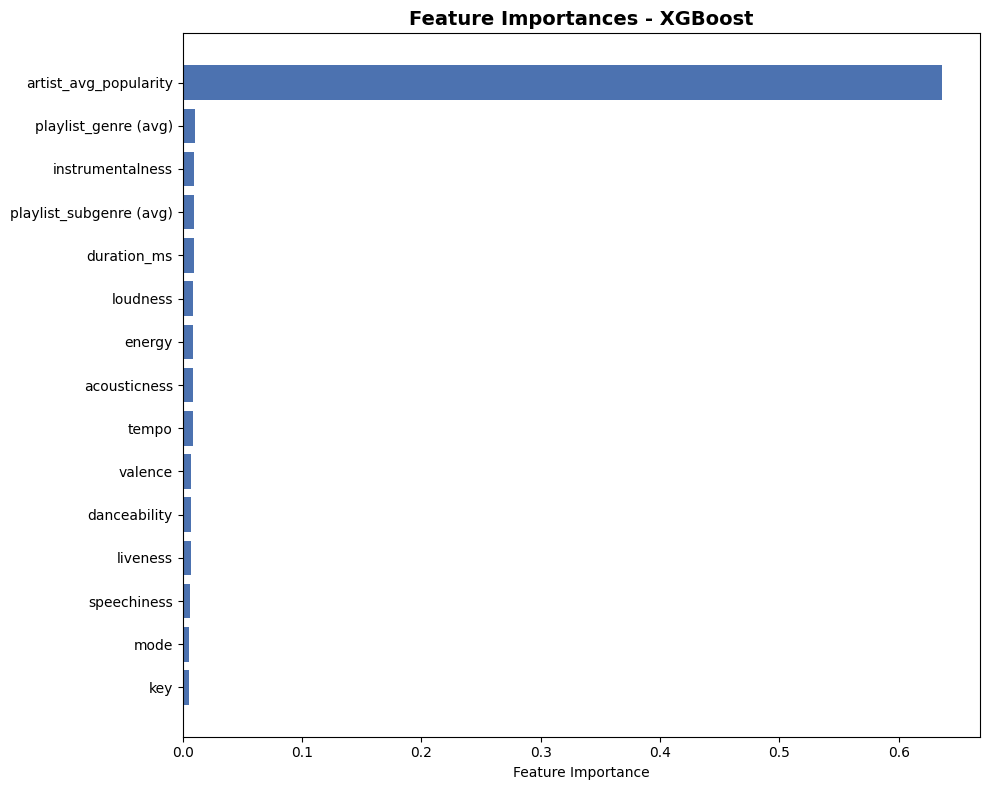

In [101]:
# feature importance for best regression model (XGBoost)
plot_grouped_feature_importance(
    xgb_search.best_estimator_, feature_names,
    title="XGBoost", color="#4C72B0"
)

## Classification: Hit or Not Hit

Regression R² topped out around 0.20, so we switched to binary classification - **"Hit"** (top 25% popularity) vs **"Not Hit"** (bottom 75%). The cutoff comes from the training set so we don't leak test data.

Training baseline classifiers, tuning with GridSearchCV, then comparing with confusion matrices and ROC curves.

Hit cutoff (75th percentile of training popularity): 58.0

Train set:
  Not Hit (0): 15718  (74.9%)
  Hit    (1):  5266  (25.1%)

Test set:
  Not Hit (0):  3940  (75.1%)
  Hit    (1):  1306  (24.9%)


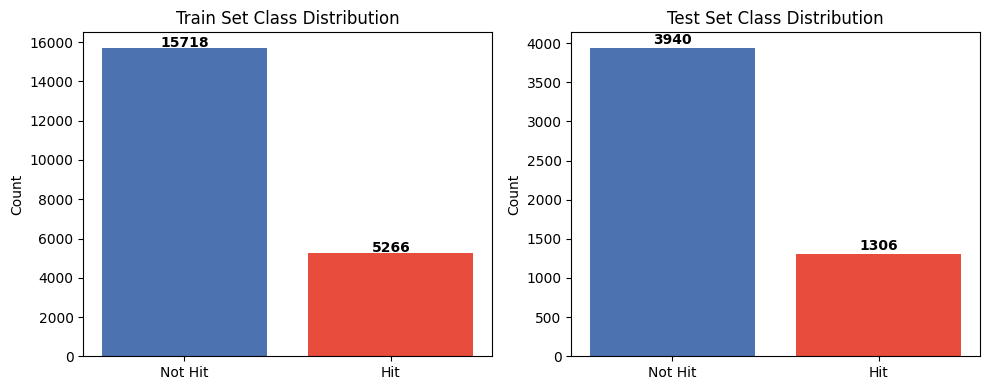


Note: we split train/test before creating labels, so the class proportions in test might be slightly different from train.


In [81]:
# binary target: top 25% = "Hit", bottom 75% = "Not Hit"
# using training set percentile so we don't leak test info
hit_cutoff = np.percentile(y_train, 75)
print(f"Hit cutoff (75th percentile of training popularity): {hit_cutoff}")

y_train_cls = (y_train >= hit_cutoff).astype(int)
y_test_cls = (y_test >= hit_cutoff).astype(int)

# check class balance
for name, y in [("Train", y_train_cls), ("Test", y_test_cls)]:
    counts = y.value_counts().sort_index()
    total = len(y)
    print(f"\n{name} set:")
    print(f"  Not Hit (0): {counts.get(0, 0):>5d}  ({counts.get(0, 0)/total*100:.1f}%)")
    print(f"  Hit    (1): {counts.get(1, 0):>5d}  ({counts.get(1, 0)/total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for name, y, ax in zip(["Train", "Test"], [y_train_cls, y_test_cls], axes):
    counts = y.value_counts().sort_index()
    ax.bar(["Not Hit", "Hit"], counts.values, color=["#4C72B0", "#E74C3C"])
    ax.set_title(f"{name} Set Class Distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nNote: we split train/test before creating labels, so the class "
      f"proportions in test might be slightly different from train.")

In [82]:
# training all 5 classifiers (no tuning yet)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

# XGBoost needs this to handle the class imbalance
n_not_hit = (y_train_cls == 0).sum()
n_hit = (y_train_cls == 1).sum()
hit_ratio = n_not_hit / n_hit
print(f"scale_pos_weight (neg/pos ratio): {hit_ratio:.2f}\n")

classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, scale_pos_weight=hit_ratio, random_state=42, verbosity=0),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=1000,
                                     early_stopping=True, validation_fraction=0.1,
                                     alpha=0.001, random_state=42),
}

baseline_cls_results = {}
baseline_cls_models = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train_cls)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test_cls, y_pred)
    prec = precision_score(y_test_cls, y_pred)
    rec = recall_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)

    baseline_cls_results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
    baseline_cls_models[name] = clf

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    print(classification_report(y_test_cls, y_pred, target_names=["Not Hit", "Hit"]))
    print()

scale_pos_weight (neg/pos ratio): 2.98

=== KNN ===
Accuracy: 0.7650  Precision: 0.5419  Recall: 0.3614  F1: 0.4336
              precision    recall  f1-score   support

     Not Hit       0.81      0.90      0.85      3940
         Hit       0.54      0.36      0.43      1306

    accuracy                           0.76      5246
   macro avg       0.68      0.63      0.64      5246
weighted avg       0.74      0.76      0.75      5246


=== Logistic Regression ===
Accuracy: 0.7589  Precision: 0.5126  Recall: 0.6371  F1: 0.5681
              precision    recall  f1-score   support

     Not Hit       0.87      0.80      0.83      3940
         Hit       0.51      0.64      0.57      1306

    accuracy                           0.76      5246
   macro avg       0.69      0.72      0.70      5246
weighted avg       0.78      0.76      0.77      5246


=== Random Forest ===
Accuracy: 0.7949  Precision: 0.6438  Recall: 0.3943  F1: 0.4891
              precision    recall  f1-score   supp

In [83]:
# tuning classifiers with GridSearchCV
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

# Logistic Regression
lr_param_grid = {
    "C": [0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
}
lr_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    param_grid=lr_param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1,
)
lr_search.fit(X_train, y_train_cls)
print(f"=== Logistic Regression (Tuned) ===")
print(f"Best params: {lr_search.best_params_}")
print(f"Best CV F1:  {lr_search.best_score_:.4f}\n")

# Random Forest
rf_cls_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 2],
}
rf_cls_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid=rf_cls_param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1,
)
rf_cls_search.fit(X_train, y_train_cls)
print(f"=== Random Forest (Tuned) ===")
print(f"Best params: {rf_cls_search.best_params_}")
print(f"Best CV F1:  {rf_cls_search.best_score_:.4f}\n")

# XGBoost
xgb_cls_param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4, 6, 8],
}
xgb_cls_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=hit_ratio, random_state=42, verbosity=0),
    param_grid=xgb_cls_param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1,
)
xgb_cls_search.fit(X_train, y_train_cls)
print(f"=== XGBoost (Tuned) ===")
print(f"Best params: {xgb_cls_search.best_params_}")
print(f"Best CV F1:  {xgb_cls_search.best_score_:.4f}\n")

# test set results for tuned models
tuned_cls_models = {
    "Logistic Regression": lr_search.best_estimator_,
    "Random Forest": rf_cls_search.best_estimator_,
    "XGBoost": xgb_cls_search.best_estimator_,
}

for name, model in tuned_cls_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_cls, y_pred)
    prec = precision_score(y_test_cls, y_pred)
    rec = recall_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)
    print(f"{name} (Tuned) - Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
=== Logistic Regression (Tuned) ===
Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1:  0.6703

Fitting 5 folds for each of 8 candidates, totalling 40 fits
=== Random Forest (Tuned) ===
Best params: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 300}
Best CV F1:  0.7032

Fitting 5 folds for each of 12 candidates, totalling 60 fits
=== XGBoost (Tuned) ===
Best params: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200}
Best CV F1:  0.7027

Logistic Regression (Tuned) - Acc: 0.7598  Prec: 0.5142  Rec: 0.6386  F1: 0.5697
Random Forest (Tuned) - Acc: 0.7932  Prec: 0.6131  Rec: 0.4587  F1: 0.5247
XGBoost (Tuned) - Acc: 0.7863  Prec: 0.5749  Rec: 0.5436  F1: 0.5588


              Model  Accuracy  Precision   Recall       F1
Logistic Regression  0.759817   0.514180 0.638591 0.569672
      Random Forest  0.793176   0.613101 0.458652 0.524748
            XGBoost  0.786313   0.574899 0.543645 0.558835


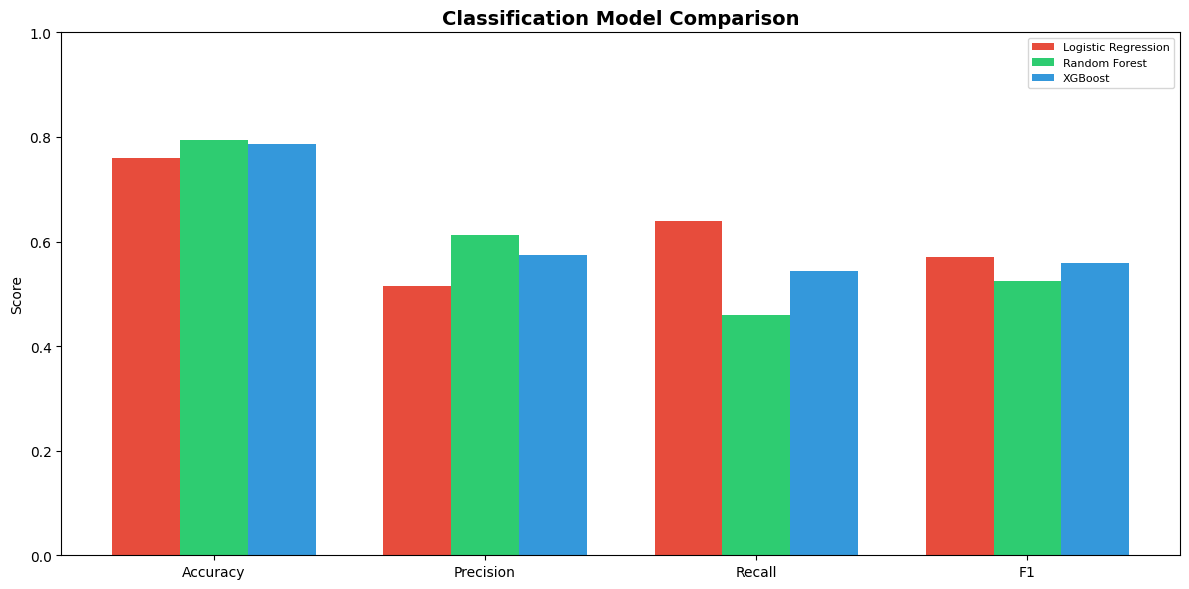

In [84]:
# comparing all classification models side by side
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

all_cls_models = {
    "Logistic Regression": lr_search.best_estimator_,
    "Random Forest": rf_cls_search.best_estimator_,
    "XGBoost": xgb_cls_search.best_estimator_,
}

rows = []
for name, model in all_cls_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_cls, y_pred)
    prec = precision_score(y_test_cls, y_pred)
    rec = recall_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)

    rows.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
    })

results_cls = pd.DataFrame(rows)
print(results_cls.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#E74C3C", "#2ECC71", "#3498DB"]
metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics))
width = 0.25

for i, (_, row) in enumerate(results_cls.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=row["Model"], color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.set_title("Classification Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

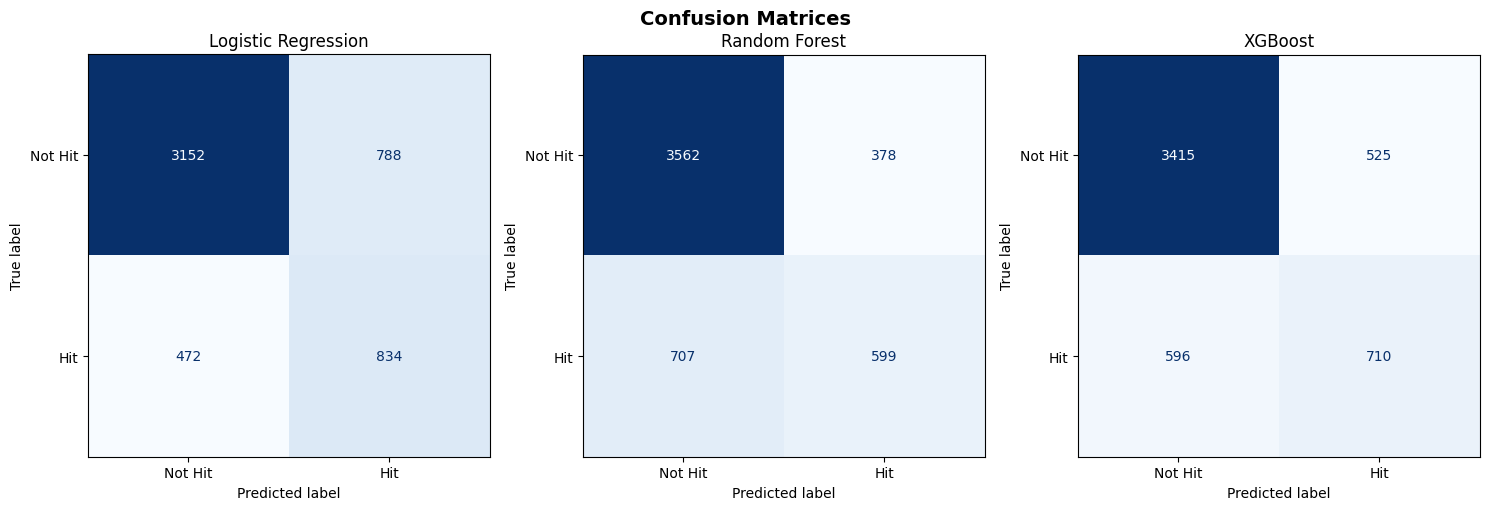

In [85]:
# confusion matrices
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, all_cls_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test_cls, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not Hit", "Hit"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

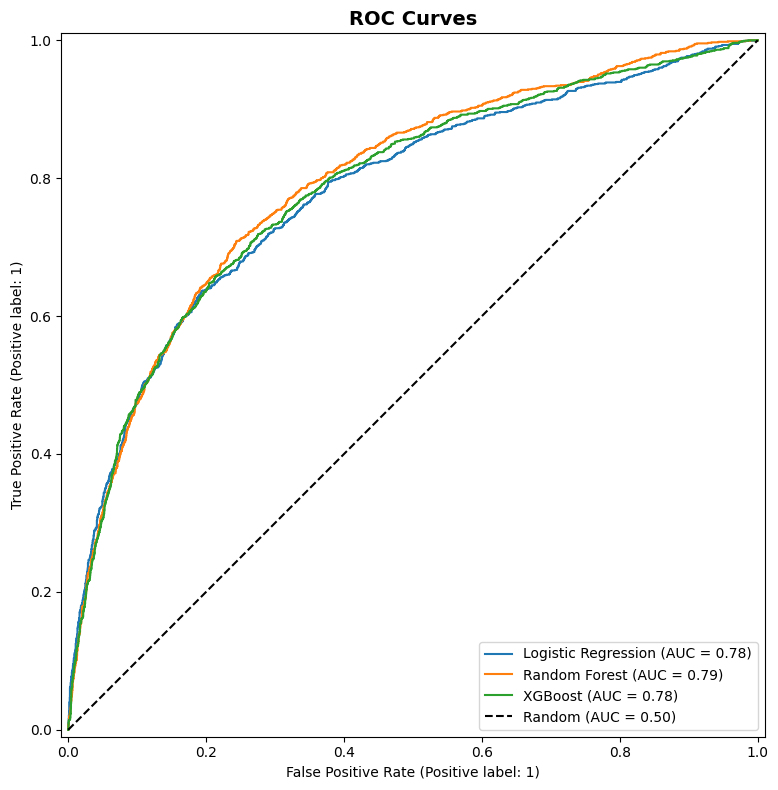

In [86]:
# ROC curves
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 8))

for name, model in all_cls_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test_cls, ax=ax, name=name)

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
ax.set_title("ROC Curves", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

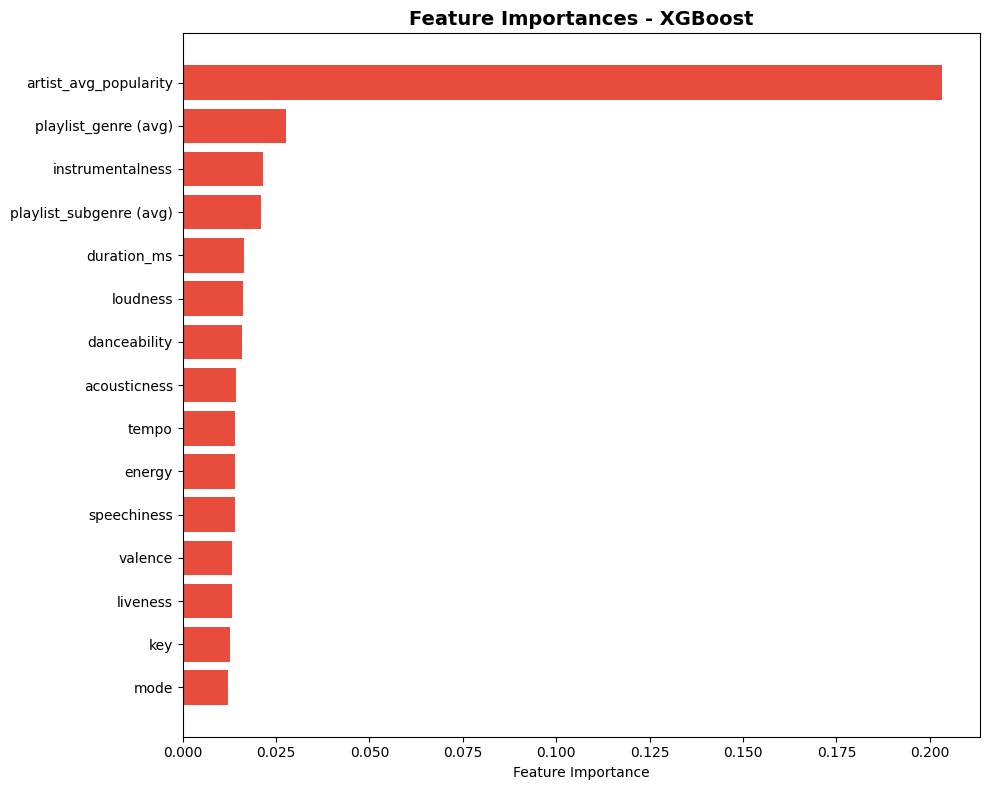

In [100]:
# feature importance for best classification model (XGBoost)
plot_grouped_feature_importance(
    xgb_cls_search.best_estimator_, feature_names,
    title="XGBoost", color="#E74C3C"
)

In [88]:
import joblib

joblib.dump(lr_search.best_estimator_, "logistic_model.pkl")
joblib.dump(xgb_cls_search.best_estimator_, "xgboost_model.pkl")
joblib.dump(rf_cls_search.best_estimator_, "random_forest_model.pkl")

['random_forest_model.pkl']

## Conclusion


This is a brief summary; a more detailed discussion of our findings can be found in the project paper linked in the README.

Our initial approach used regression to predict track popularity scores directly, but performance was poor across all models (R² ≈ 0.20), indicating that the models
explained very little of the variance in popularity. We pivoted to binary classification, framing the problem as predicting whether a song is a "Hit" (top 25%
popularity) or "Not Hit" (bottom 75%).

Early classification results were also underwhelming, so we revisited our feature selection. Reintroducing genre and subgenre as one-hot encoded features led to a
noticeable increase in F1 scores. We also engineered a new feature, artist_avg_popularity, by computing each artist's mean popularity from the training set. This
significantly improved model performance, though it introduces bias, the model partially relies on artist reputation rather than the song's own characteristics.

Overall, our original goal was to predict track popularity from audio features alone. The weak regression results and the outsized importance of artist_avg_popularity in
our classification models both point to the same conclusion: audio features alone are not sufficient to predict song popularity. Factors like artist
recognition, marketing, branding and playlist placement likely play a much larger role than danceability, tempo, or loudness.